In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

import joblib

Carregar testes

In [13]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

Inicializar Modelo

In [14]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42)
}


Treinar e avaliar modelos

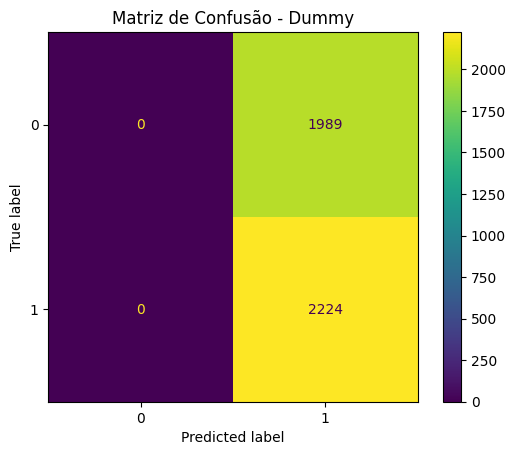

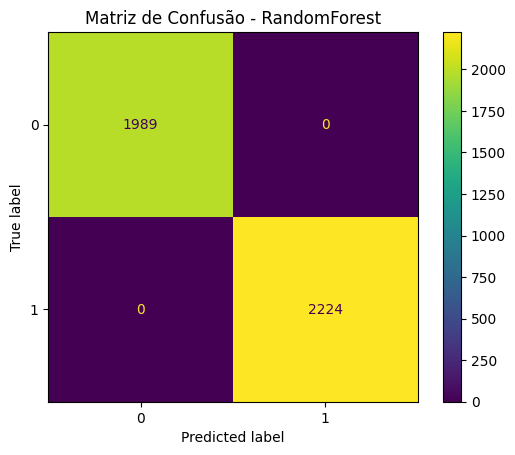

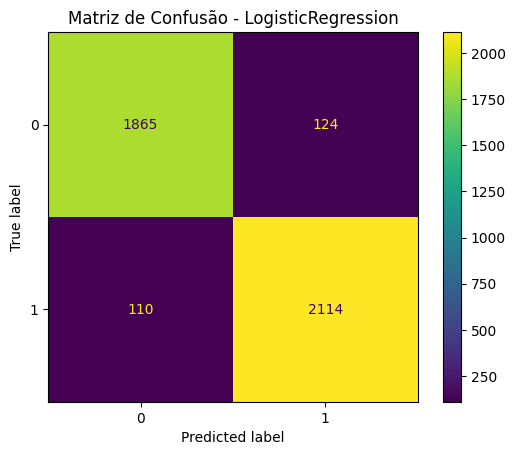

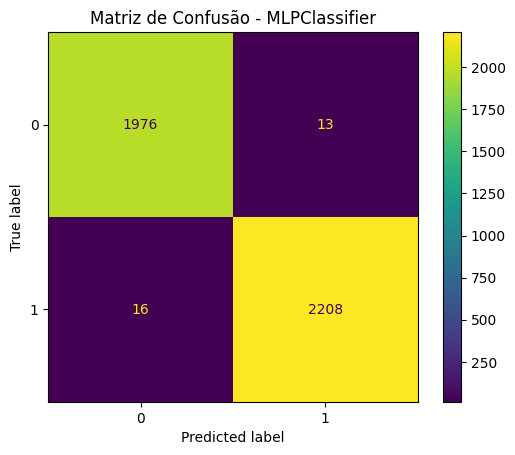

[LightGBM] [Info] Number of positive: 8896, number of negative: 7954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000458 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2383
[LightGBM] [Info] Number of data points in the train set: 16850, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

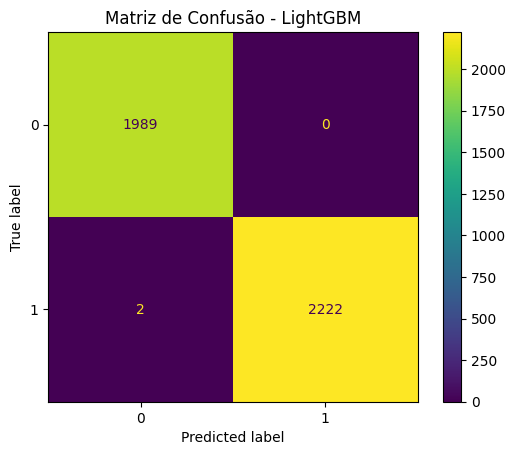

In [15]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

    # ▸ Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão - {name}")
    plt.grid(False)
    plt.show()

Tabela de comapração de resultados

In [16]:
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
display(results_df)

,Modelo,Accuracy,F1-score,ROC-AUC
1,RandomForest,1.000000,1.000000,1.000000
4,LightGBM,0.999525,0.999550,1.000000
3,MLPClassifier,0.993117,0.993476,0.998845
2,LogisticRegression,0.944458,0.947557,0.980778
0,Dummy,0.527890,0.691005,0.500000


Curvas de Roc

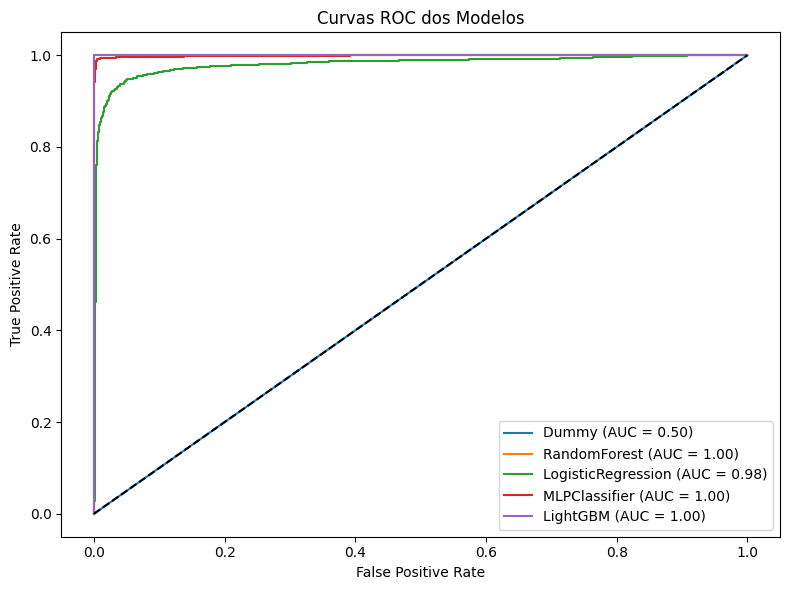

In [17]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC dos Modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Importância de variáveis para modelos baseados em árvore

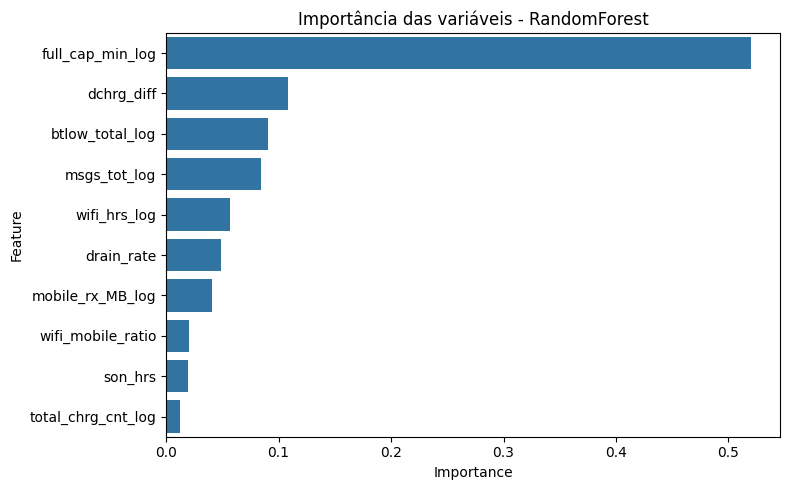

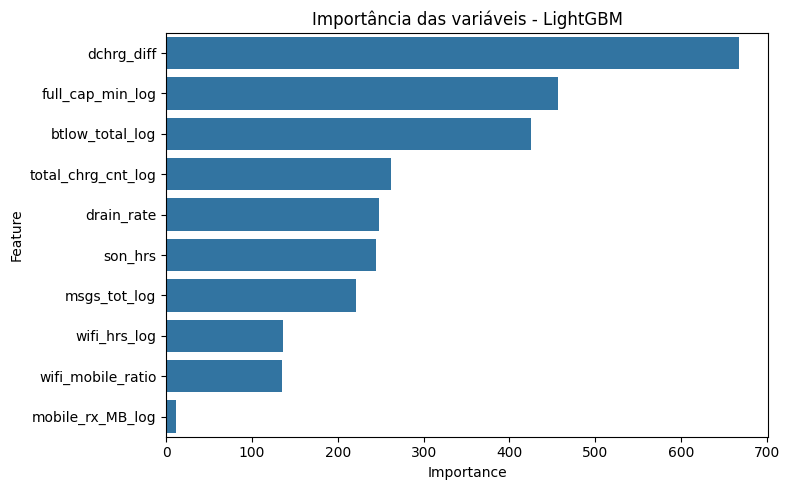

In [18]:
for name in ["RandomForest", "LightGBM"]:
    model = models[name]
    importances = model.feature_importances_
    feat_names = X_train.columns

    imp_df = pd.DataFrame({"Feature": feat_names, "Importance": importances})
    imp_df = imp_df.sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x="Importance", y="Feature")
    plt.title(f"Importância das variáveis - {name}")
    plt.tight_layout()
    plt.show()

In [19]:
print("✅ Modelagem concluída. Resultados disponíveis na tabela e gráficos.")

✅ Modelagem concluída. Resultados disponíveis na tabela e gráficos.
